# Air Quality Index (AQI) Prediction
**Domain:** Environment & Energy  
**Problem Type:** Regression  
**Dataset:** Air Quality Data in India (2015-2020) — CPCB / Kaggle

---
## Part 1 - Problem Definition

**What is the problem?**  
Air Quality Index (AQI) tells us how polluted the air is on a given day. A high AQI means the air is dangerous to breathe. We want to predict the AQI value using pollutant data like PM2.5, PM10, NO2, SO2, CO, etc.

**Why is this problem important?**  
Bad air quality causes serious health problems like asthma, lung disease, and heart problems. India has some of the most polluted cities in the world. If we can predict AQI in advance, the government can issue health warnings and people can plan their activities accordingly.

**Who will benefit?**  
- Citizens - they can avoid going outside on bad air days
- Government - can take action to reduce pollution
- Hospitals - can prepare for more patients on high-AQI days

**Why is Machine Learning suitable?**  
AQI depends on many pollutants at the same time and the relationship is complex and non-linear. Machine Learning can learn these patterns from past data and make accurate predictions.

---
## Dataset Description

| Property | Details |
|---|---|
| Dataset Name | Air Quality Data in India (2015-2020) |
| Source | Kaggle / CPCB (Central Pollution Control Board), Govt. of India |
| File | city_day.csv |
| Number of Rows | 29,531 |
| Number of Columns | 16 |
| Target Variable | AQI (numeric value) |
| Time Period | 2015 to 2020 |
| Cities | 26 Indian cities |

**Columns:**
- City - name of the city
- Date - date of measurement
- PM2.5 - fine particulate matter (very harmful)
- PM10 - coarse particulate matter
- NO, NO2, NOx - nitrogen compounds
- NH3 - ammonia
- CO - carbon monoxide
- SO2 - sulphur dioxide
- O3 - ozone
- Benzene, Toluene, Xylene - organic chemicals
- AQI - Air Quality Index (this is what we want to predict)
- AQI_Bucket - category like Good, Moderate, Poor, Severe

**Dataset Limitations:**
- About 16% of AQI values are missing
- No weather data like temperature or humidity
- Data only goes up to July 2020

---
## Step 1 - Import Libraries

In [1]:
# Importing all the libraries we need

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 2 - Load the Dataset

In [2]:
# Load the CSV file into a dataframe
df = pd.read_csv('../Dataset/AQI/city_day.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print()
df.head(10)

Dataset loaded successfully!
Shape: (29531, 16)



,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
5,Ahmedabad,2015-01-06,NaN,NaN,45.41,38.48,81.50,NaN,45.41,45.76,46.51,5.42,10.83,1.93,NaN,NaN
6,Ahmedabad,2015-01-07,NaN,NaN,112.16,40.62,130.77,NaN,112.16,32.28,33.47,0.00,0.00,0.00,NaN,NaN
7,Ahmedabad,2015-01-08,NaN,NaN,80.87,36.74,96.75,NaN,80.87,38.54,31.89,0.00,0.00,0.00,NaN,NaN
8,Ahmedabad,2015-01-09,NaN,NaN,29.16,31.00,48.00,NaN,29.16,58.68,25.75,0.00,0.00,0.00,NaN,NaN
9,Ahmedabad,2015-01-10,NaN,NaN,NaN,7.04,0.00,NaN,NaN,8.29,4.55,0.00,0.00,0.00,NaN,NaN


---
## Step 3 - Data Understanding

In [3]:
# Check the data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


In [4]:
# Basic statistics like mean, min, max etc.
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [5]:
# Check how many values are missing in each column
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [6]:
# Check the unique cities
print("Cities in the dataset:")
print(df['City'].unique())
print()
print("Total cities:", df['City'].nunique())
print("Date range:", df['Date'].min(), "to", df['Date'].max())

Cities in the dataset:
<StringArray>
[         'Ahmedabad',             'Aizawl',          'Amaravati',
           'Amritsar',          'Bengaluru',             'Bhopal',
       'Brajrajnagar',         'Chandigarh',            'Chennai',
         'Coimbatore',              'Delhi',          'Ernakulam',
           'Gurugram',           'Guwahati',          'Hyderabad',
             'Jaipur',         'Jorapokhar',              'Kochi',
            'Kolkata',            'Lucknow',             'Mumbai',
              'Patna',           'Shillong',            'Talcher',
 'Thiruvananthapuram',      'Visakhapatnam']
Length: 26, dtype: str

Total cities: 26
Date range: 2015-01-01 to 2020-07-01


In [7]:
# Check the AQI categories
print("AQI Category counts:")
print(df['AQI_Bucket'].value_counts())

AQI Category counts:
AQI_Bucket
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe          1338
Name: count, dtype: int64


---
## Step 4 - Data Preprocessing

We will clean the data step by step before training the model.

In [8]:
# Step 4.1 - Remove rows where AQI is missing
# We cannot predict AQI if we don't have the actual AQI value for training

print("Rows before:", len(df))
df = df.dropna(subset=['AQI'])
print("Rows after removing missing AQI:", len(df))

Rows before: 29531
Rows after removing missing AQI: 24850


In [9]:
# Step 4.2 - Remove duplicate rows
# Duplicate rows can confuse the model

print("Rows before:", len(df))
df = df.drop_duplicates()
print("Rows after removing duplicates:", len(df))

Rows before: 24850
Rows after removing duplicates: 24850


In [10]:
# Step 4.3 - Convert Date column and extract useful parts
# ML models cannot use dates directly so we extract Year, Month, Day
# Month is important because air quality is different in winter vs summer

df['Date'] = pd.to_datetime(df['Date'])

df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day']   = df['Date'].dt.day

# We don't need the Date column anymore
df = df.drop('Date', axis=1)

print("Date column converted. New columns added: Year, Month, Day")
df.head(3)

Date column converted. New columns added: Year, Month, Day


,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,Day
28,Ahmedabad,83.13,NaN,6.93,28.71,33.72,NaN,6.93,49.52,59.76,0.02,0.00,3.14,209.0,Poor,2015,1,29
29,Ahmedabad,79.84,NaN,13.85,28.68,41.08,NaN,13.85,48.49,97.07,0.04,0.00,4.81,328.0,Very Poor,2015,1,30
30,Ahmedabad,94.52,NaN,24.39,32.66,52.61,NaN,24.39,67.39,111.33,0.24,0.01,7.67,514.0,Severe,2015,1,31


In [11]:
# Step 4.4 - Encode the City column
# ML models only work with numbers, not text
# LabelEncoder converts city names to numbers like Delhi=7, Mumbai=15 etc.

le = LabelEncoder()
df['City'] = le.fit_transform(df['City'])

# Remove AQI_Bucket column - it is created from AQI so we should not use it as a feature
df = df.drop('AQI_Bucket', axis=1)

print("City column encoded and AQI_Bucket removed")
df.head(3)

City column encoded and AQI_Bucket removed


,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Year,Month,Day
28,0,83.13,NaN,6.93,28.71,33.72,NaN,6.93,49.52,59.76,0.02,0.00,3.14,209.0,2015,1,29
29,0,79.84,NaN,13.85,28.68,41.08,NaN,13.85,48.49,97.07,0.04,0.00,4.81,328.0,2015,1,30
30,0,94.52,NaN,24.39,32.66,52.61,NaN,24.39,67.39,111.33,0.24,0.01,7.67,514.0,2015,1,31


In [12]:
# Step 4.5 - Fill remaining missing values using median
# Some pollutant columns still have missing values
# We fill them with the median value of that column
# We use median instead of mean because pollutant data has outliers

df = df.fillna(df.median(numeric_only=True))

print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
City       0
PM2.5      0
PM10       0
NO         0
NO2        0
NOx        0
NH3        0
CO         0
SO2        0
O3         0
Benzene    0
Toluene    0
Xylene     0
AQI        0
Year       0
Month      0
Day        0
dtype: int64


In [13]:
# Check the final cleaned dataset
print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (24850, 17)


,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Year,Month,Day
28,0,83.13,96.18,6.93,28.71,33.72,16.31,6.93,49.52,59.76,0.02,0.00,3.14,209.0,2015,1,29
29,0,79.84,96.18,13.85,28.68,41.08,16.31,13.85,48.49,97.07,0.04,0.00,4.81,328.0,2015,1,30
30,0,94.52,96.18,24.39,32.66,52.61,16.31,24.39,67.39,111.33,0.24,0.01,7.67,514.0,2015,1,31
31,0,135.99,96.18,43.48,42.08,84.57,16.31,43.48,75.23,102.70,0.40,0.04,25.87,782.0,2015,2,1
32,0,178.33,96.18,54.56,35.31,72.80,16.31,54.56,55.04,107.38,0.46,0.06,35.61,914.0,2015,2,2


---
## Step 5 - Exploratory Data Analysis (EDA)

We will create visualizations to understand the data better. We need at least 5 visualizations.

In [14]:
# Reload the original data for EDA so we can use City names and AQI_Bucket
df_eda = pd.read_csv('../Dataset/AQI/city_day.csv')
df_eda['Date'] = pd.to_datetime(df_eda['Date'])
df_eda['Month'] = df_eda['Date'].dt.month
df_eda['Year']  = df_eda['Date'].dt.year
df_eda = df_eda.dropna(subset=['AQI'])
print("EDA dataframe shape:", df_eda.shape)

EDA dataframe shape: (24850, 18)


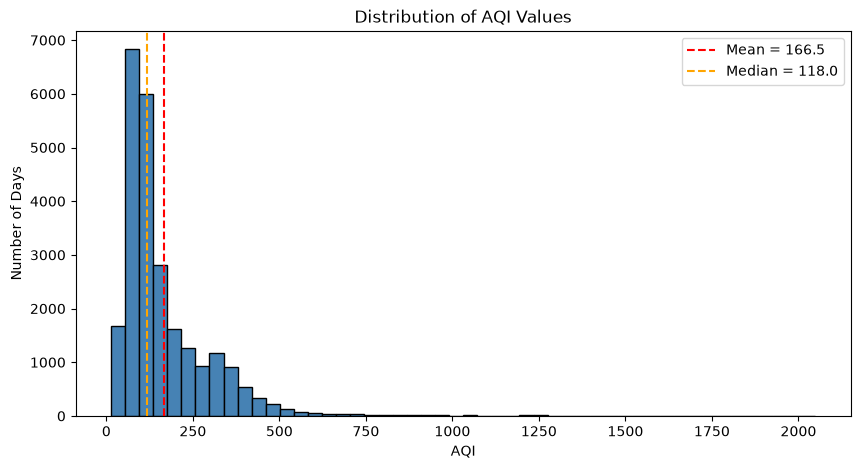

In [39]:
# Visualization 1 - Histogram of AQI values
# This shows how AQI is distributed - most days low or high?

plt.figure(figsize=(10, 5))
plt.hist(df_eda['AQI'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of AQI Values')
plt.xlabel('AQI')
plt.ylabel('Number of Days')
plt.axvline(df_eda['AQI'].mean(), color='red', linestyle='--', label='Mean = ' + str(round(df_eda['AQI'].mean(), 1)))
plt.axvline(df_eda['AQI'].median(), color='orange', linestyle='--', label='Median = ' + str(round(df_eda['AQI'].median(), 1)))
plt.legend()
plt.show()


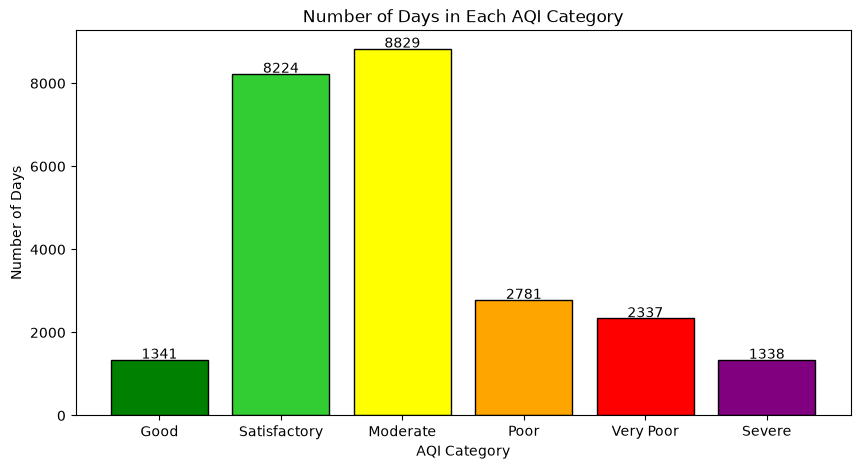

In [40]:
# Visualization 2 - Count plot of AQI categories
# This shows how many days fall in each category

bucket_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
counts = df_eda['AQI_Bucket'].value_counts().reindex(bucket_order, fill_value=0)

plt.figure(figsize=(10, 5))
colors = ['green', 'limegreen', 'yellow', 'orange', 'red', 'purple']
plt.bar(counts.index, counts.values, color=colors, edgecolor='black')
plt.title('Number of Days in Each AQI Category')
plt.xlabel('AQI Category')
plt.ylabel('Number of Days')
for i in range(len(counts)):
    plt.text(i, counts.values[i] + 30, str(counts.values[i]), ha='center', fontsize=10)
plt.show()

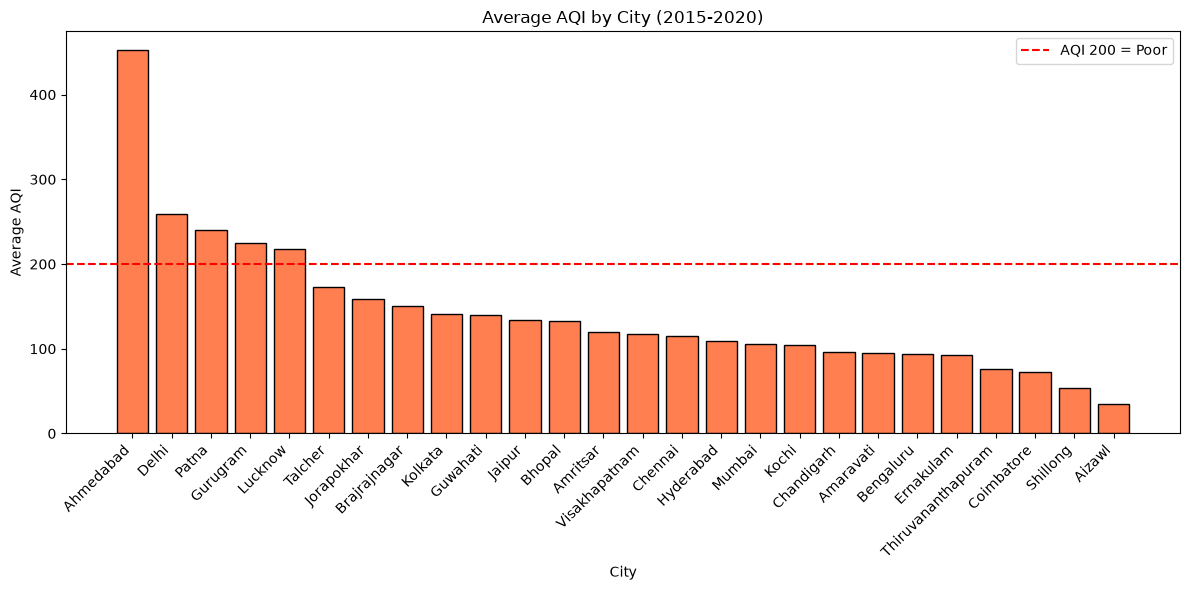

In [41]:
# Visualization 3 - Bar chart of Average AQI by City
# Which cities have the worst air quality?

city_aqi = df_eda.groupby('City')['AQI'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(city_aqi.index, city_aqi.values, color='coral', edgecolor='black')
plt.title('Average AQI by City (2015-2020)')
plt.xlabel('City')
plt.ylabel('Average AQI')
plt.xticks(rotation=45, ha='right')
plt.axhline(200, color='red', linestyle='--', label='AQI 200 = Poor')
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

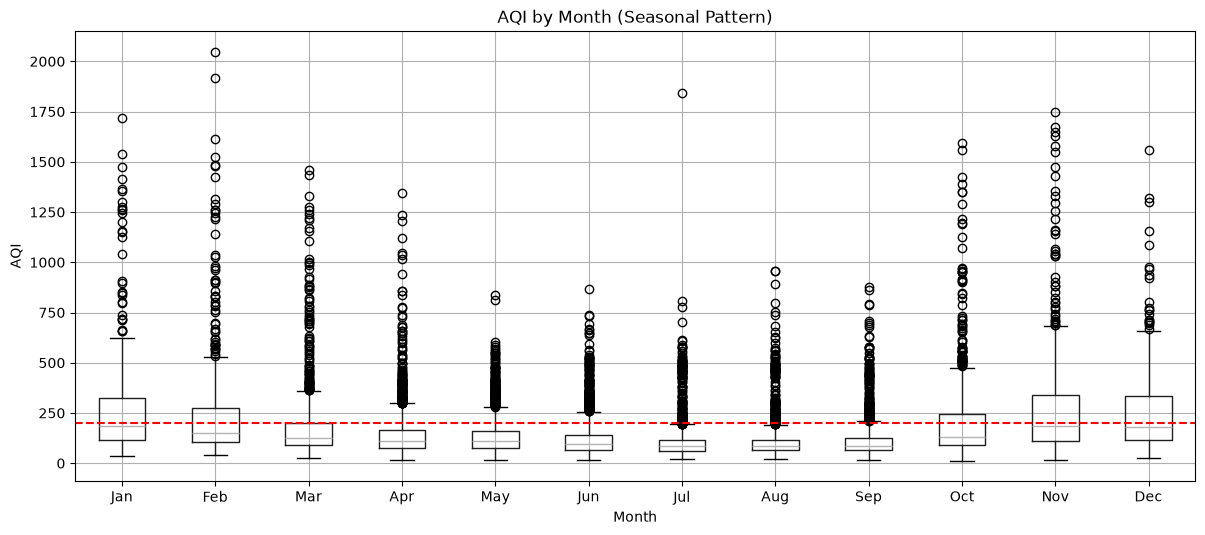

In [42]:
# Visualization 4 - Box plot of AQI by Month
# Does AQI change across months? (seasonal pattern)

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(14, 6))
df_eda.boxplot(column='AQI', by='Month', figsize=(14, 6))
plt.title('AQI by Month (Seasonal Pattern)')
plt.suptitle('')  # Remove default title
plt.xlabel('Month')
plt.ylabel('AQI')
plt.xticks(ticks=range(1, 13), labels=month_names)
plt.axhline(200, color='red', linestyle='--', label='AQI 200')
plt.show()


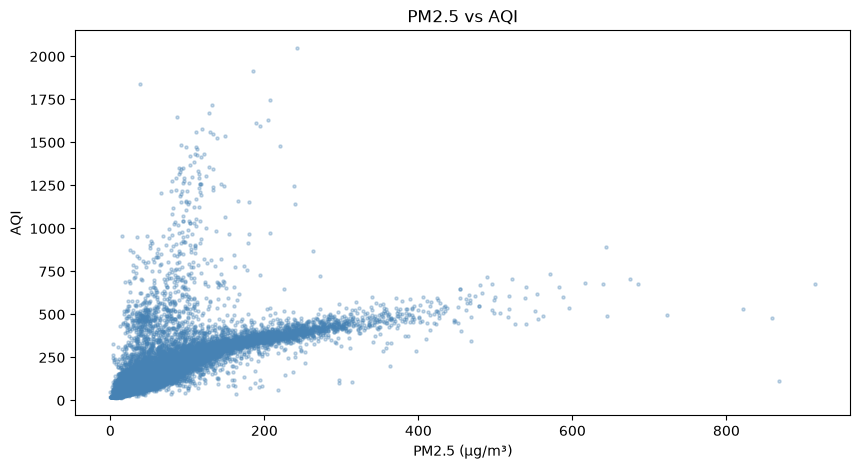

In [47]:
# Visualization 5 - Scatter plot of PM2.5 vs AQI
# Is PM2.5 related to AQI?

plt.figure(figsize=(10, 5))
plt.scatter(df_eda['PM2.5'], df_eda['AQI'], alpha=0.3, color='steelblue', s=5)
plt.title('PM2.5 vs AQI')
plt.xlabel('PM2.5 (µg/m³)')
plt.ylabel('AQI')
plt.show()

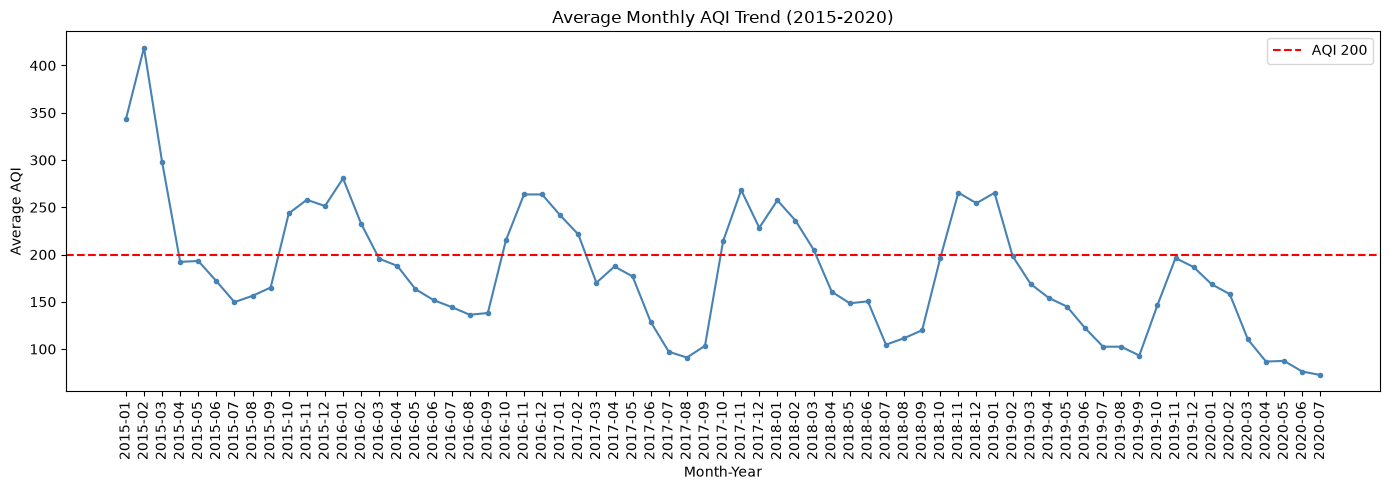

In [44]:
# Visualization 6 - Line chart of AQI over time
# How has AQI changed from 2015 to 2020?

monthly = df_eda.groupby(['Year', 'Month'])['AQI'].mean().reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 5))
plt.plot(monthly['Period'], monthly['AQI'], color='steelblue', marker='o', markersize=3)
plt.title('Average Monthly AQI Trend (2015-2020)')
plt.xlabel('Month-Year')
plt.ylabel('Average AQI')
plt.xticks(rotation=90)
plt.axhline(200, color='red', linestyle='--', label='AQI 200')
plt.legend()
plt.tight_layout()
plt.show()


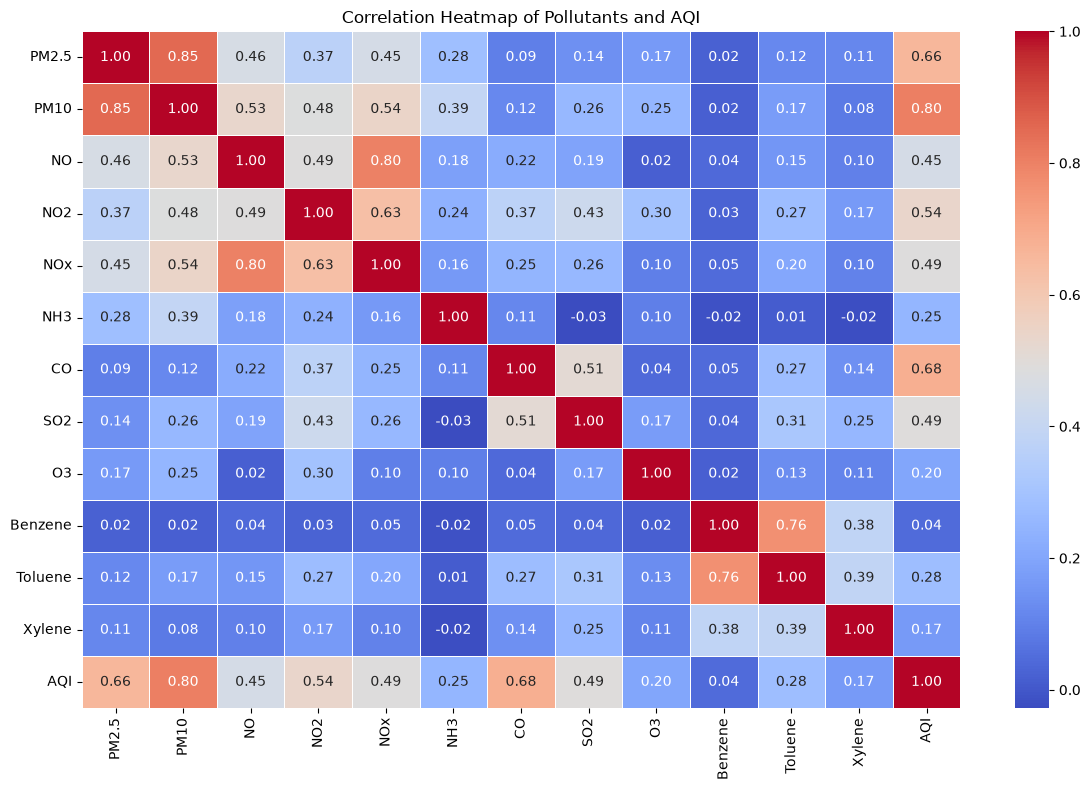

In [45]:
# Visualization 7 - Correlation Heatmap
# Which pollutants are most related to AQI?

cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']
corr = df_eda[cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Pollutants and AQI')
plt.tight_layout()
plt.show()

---
## Step 6 - Feature Selection and Split

Separate the features (X) and target (y), then split into training and testing sets.

In [22]:
# Separate features and target variable
# X = all columns except AQI
# y = AQI column (what we want to predict)

X = df.drop('AQI', axis=1)
y = df['AQI']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print()
print("Feature columns used:")
print(list(X.columns))

Features (X) shape: (24850, 16)
Target (y) shape: (24850,)

Feature columns used:
['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'Year', 'Month', 'Day']


In [23]:
# Split the data into training and testing sets
# 80% for training, 20% for testing
# random_state=42 means we get the same split every time we run the code

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", len(X_train))
print("Testing set size:", len(X_test))

Training set size: 19880
Testing set size: 4970


In [24]:
# Feature Scaling using StandardScaler
# This is needed for Linear Regression
# It makes all features have same scale (mean=0, std=1)
# We fit on training data only to avoid data leakage

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling done!")

Feature scaling done!


---
## Step 7 - Model Training

We will train 4 different regression models and compare their performance.

In [25]:
# Model 1 - Linear Regression
# Simplest model. Draws a straight line to fit the data.
# Good as a baseline to compare with other models.

model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)
print("Linear Regression training done!")

Linear Regression training done!


In [26]:
# Model 2 - Decision Tree Regression
# Splits data into branches based on conditions, like a flowchart.
# max_depth=8 limits how deep the tree can grow to prevent overfitting.
# Tree models don't need feature scaling.

model_dt = DecisionTreeRegressor(max_depth=8, random_state=42)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)
print("Decision Tree training done!")

Decision Tree training done!


In [27]:
# Model 3 - Random Forest Regression
# Creates many Decision Trees and averages their predictions.
# More accurate than a single Decision Tree.
# n_estimators=100 means we create 100 trees.

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
print("Random Forest training done!")

Random Forest training done!


In [28]:
# Model 4 - Gradient Boosting Regression
# Builds trees one by one, each tree fixing the errors of the previous one.
# Usually gives very good accuracy.

model_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
model_gb.fit(X_train, y_train)

y_pred_gb = model_gb.predict(X_test)
print("Gradient Boosting training done!")

Gradient Boosting training done!


---
## Step 8 - Model Evaluation

For regression problems we check:
- **MAE** (Mean Absolute Error) - average error in AQI units. Lower is better.
- **MSE** (Mean Squared Error) - penalizes big errors more. Lower is better.
- **RMSE** (Root Mean Squared Error) - square root of MSE. Same unit as AQI. Lower is better.
- **R² Score** - how much of the AQI variation the model explains. Higher is better. Max value is 1.0.

In [29]:
# Calculate metrics for all 4 models

# Linear Regression
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

# Decision Tree
mae_dt  = mean_absolute_error(y_test, y_pred_dt)
mse_dt  = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt   = r2_score(y_test, y_pred_dt)

# Random Forest
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

# Gradient Boosting
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
mse_gb  = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb   = r2_score(y_test, y_pred_gb)

print("Evaluation done for all 4 models!")

Evaluation done for all 4 models!


In [30]:
# Print results for each model

print("="*55)
print("Linear Regression Results")
print("  MAE  :", round(mae_lr, 2))
print("  MSE  :", round(mse_lr, 2))
print("  RMSE :", round(rmse_lr, 2))
print("  R2   :", round(r2_lr, 4))

print("="*55)
print("Decision Tree Results")
print("  MAE  :", round(mae_dt, 2))
print("  MSE  :", round(mse_dt, 2))
print("  RMSE :", round(rmse_dt, 2))
print("  R2   :", round(r2_dt, 4))

print("="*55)
print("Random Forest Results")
print("  MAE  :", round(mae_rf, 2))
print("  MSE  :", round(mse_rf, 2))
print("  RMSE :", round(rmse_rf, 2))
print("  R2   :", round(r2_rf, 4))

print("="*55)
print("Gradient Boosting Results")
print("  MAE  :", round(mae_gb, 2))
print("  MSE  :", round(mse_gb, 2))
print("  RMSE :", round(rmse_gb, 2))
print("  R2   :", round(r2_gb, 4))

Linear Regression Results
  MAE  : 30.99
  MSE  : 3513.09
  RMSE : 59.27
  R2   : 0.8081
Decision Tree Results
  MAE  : 25.68
  MSE  : 2487.22
  RMSE : 49.87
  R2   : 0.8642
Random Forest Results
  MAE  : 20.5
  MSE  : 1630.9
  RMSE : 40.38
  R2   : 0.9109
Gradient Boosting Results
  MAE  : 23.39
  MSE  : 1869.55
  RMSE : 43.24
  R2   : 0.8979


---
## Step 9 - Model Comparison

In [31]:
# Create a comparison table

comparison = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'MAE':   [round(mae_lr,2), round(mae_dt,2), round(mae_rf,2), round(mae_gb,2)],
    'MSE':   [round(mse_lr,2), round(mse_dt,2), round(mse_rf,2), round(mse_gb,2)],
    'RMSE':  [round(rmse_lr,2), round(rmse_dt,2), round(rmse_rf,2), round(rmse_gb,2)],
    'R2 Score': [round(r2_lr,4), round(r2_dt,4), round(r2_rf,4), round(r2_gb,4)]
}

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

            Model   MAE     MSE  RMSE  R2 Score
Linear Regression 30.99 3513.09 59.27    0.8081
    Decision Tree 25.68 2487.22 49.87    0.8642
    Random Forest 20.50 1630.90 40.38    0.9109
Gradient Boosting 23.39 1869.55 43.24    0.8979


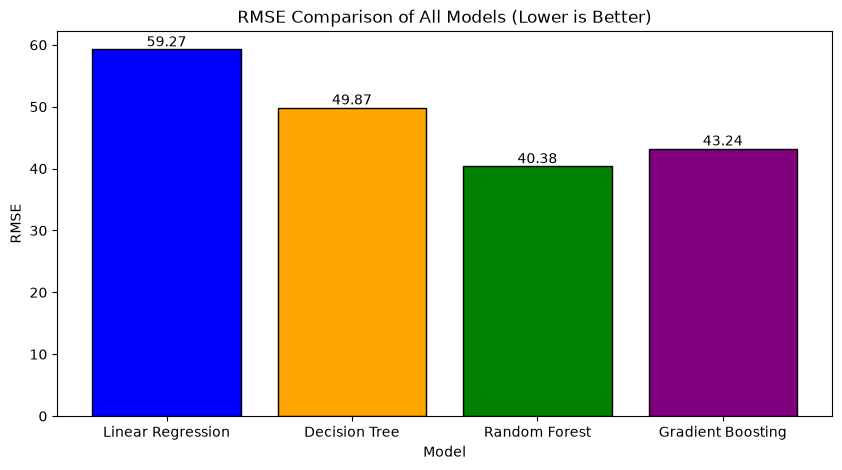

In [32]:
# Bar chart comparing RMSE of all models
models = comparison_df['Model']
rmse_values = comparison_df['RMSE']

plt.figure(figsize=(10, 5))
plt.bar(models, rmse_values, color=['blue', 'orange', 'green', 'purple'], edgecolor='black')
plt.title('RMSE Comparison of All Models (Lower is Better)')
plt.xlabel('Model')
plt.ylabel('RMSE')
for i in range(len(models)):
    plt.text(i, rmse_values.values[i] + 0.5, str(rmse_values.values[i]), ha='center', fontsize=10)
plt.show()

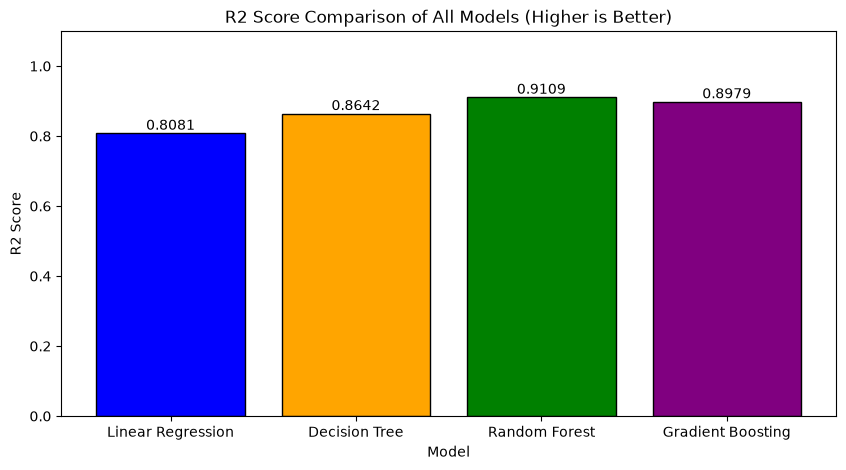

In [33]:
# Bar chart comparing R2 Score of all models
r2_values = comparison_df['R2 Score']

plt.figure(figsize=(10, 5))
plt.bar(models, r2_values, color=['blue', 'orange', 'green', 'purple'], edgecolor='black')
plt.title('R2 Score Comparison of All Models (Higher is Better)')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.ylim(0, 1.1)
for i in range(len(models)):
    plt.text(i, r2_values.values[i] + 0.01, str(r2_values.values[i]), ha='center', fontsize=10)
plt.show()

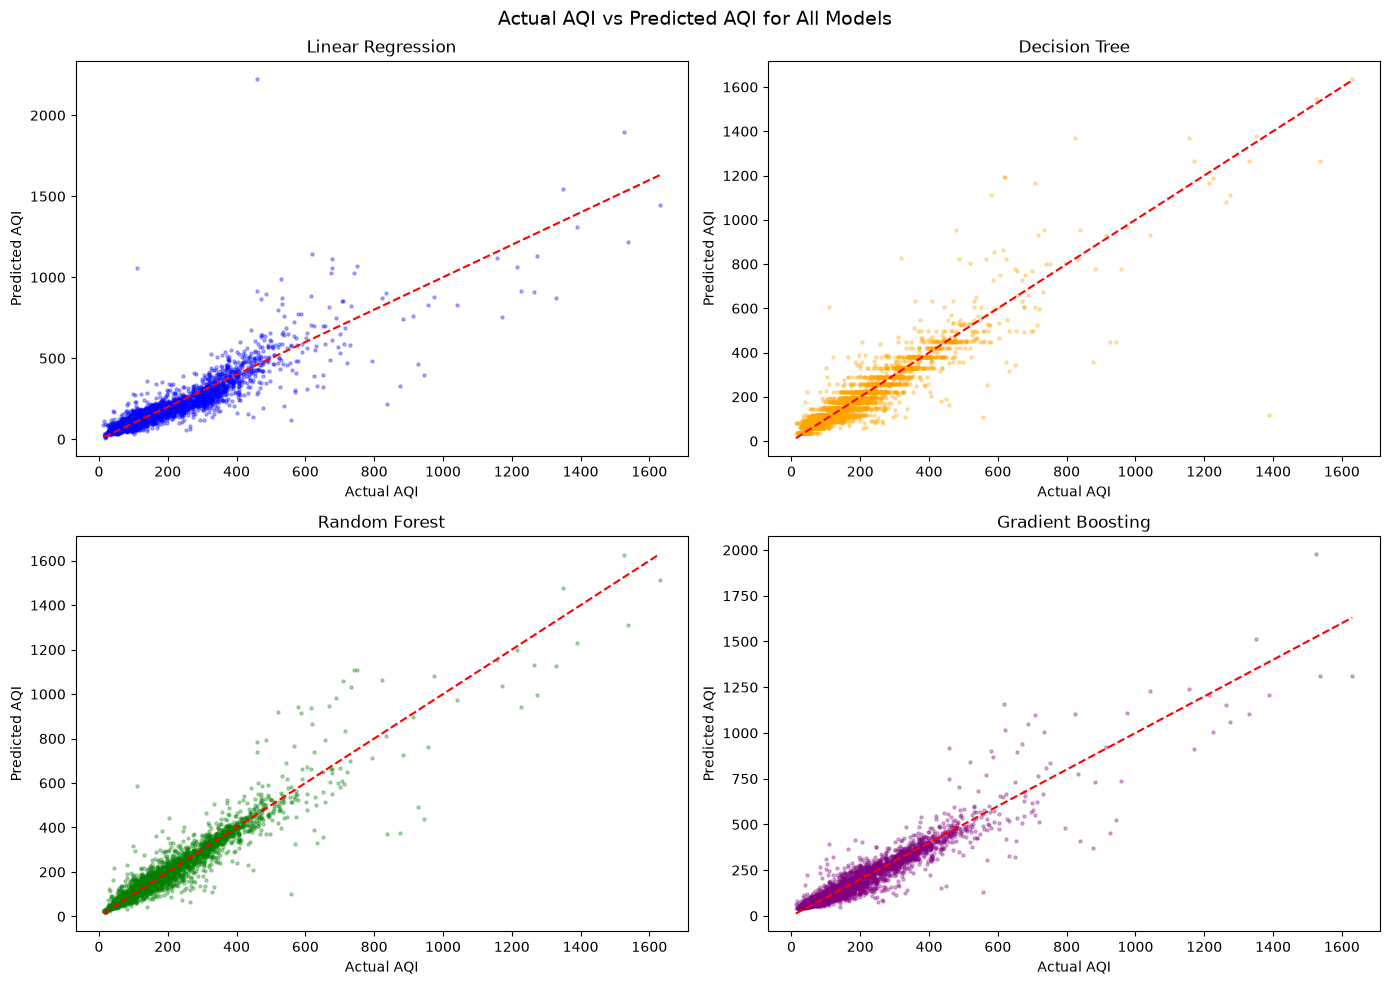

In [34]:
# Plot Actual vs Predicted for all models

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].scatter(y_test, y_pred_lr, alpha=0.3, s=5, color='blue')
axes[0][0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0][0].set_title('Linear Regression')
axes[0][0].set_xlabel('Actual AQI')
axes[0][0].set_ylabel('Predicted AQI')

axes[0][1].scatter(y_test, y_pred_dt, alpha=0.3, s=5, color='orange')
axes[0][1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0][1].set_title('Decision Tree')
axes[0][1].set_xlabel('Actual AQI')
axes[0][1].set_ylabel('Predicted AQI')

axes[1][0].scatter(y_test, y_pred_rf, alpha=0.3, s=5, color='green')
axes[1][0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1][0].set_title('Random Forest')
axes[1][0].set_xlabel('Actual AQI')
axes[1][0].set_ylabel('Predicted AQI')

axes[1][1].scatter(y_test, y_pred_gb, alpha=0.3, s=5, color='purple')
axes[1][1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1][1].set_title('Gradient Boosting')
axes[1][1].set_xlabel('Actual AQI')
axes[1][1].set_ylabel('Predicted AQI')

plt.suptitle('Actual AQI vs Predicted AQI for All Models', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 10 - Best Model Selection and Feature Importance

In [35]:
# Find the best model based on highest R2 Score
best_index = comparison_df['R2 Score'].idxmax()
best_row = comparison_df.loc[best_index]

print("Best Model:", best_row['Model'])
print("MAE  :", best_row['MAE'])
print("RMSE :", best_row['RMSE'])
print("R2   :", best_row['R2 Score'])
print()
print("Why this model is best:")
print("It has the highest R2 Score which means it explains more variance in AQI.")
print("It also has the lowest RMSE which means predictions are close to actual values.")
print("Ensemble models like Random Forest and Gradient Boosting work well because")
print("they combine many trees to make a better prediction.")

Best Model: Random Forest
MAE  : 20.5
RMSE : 40.38
R2   : 0.9109

Why this model is best:
It has the highest R2 Score which means it explains more variance in AQI.
It also has the lowest RMSE which means predictions are close to actual values.
Ensemble models like Random Forest and Gradient Boosting work well because
they combine many trees to make a better prediction.


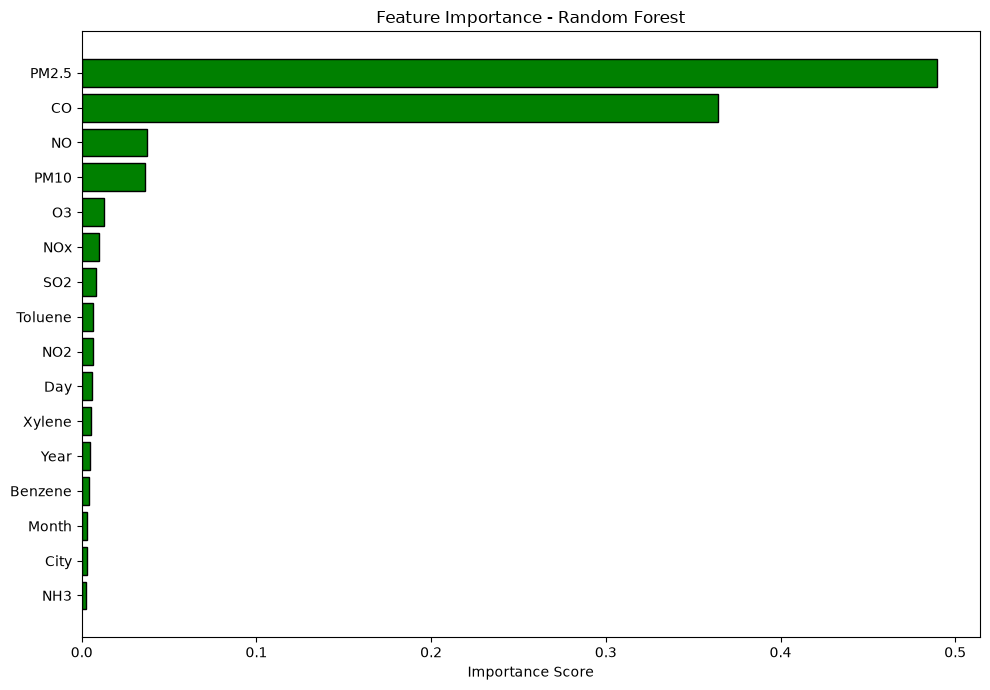

Insight: PM2.5 and PM10 are the most important features for predicting AQI.


In [36]:
# Feature importance from Random Forest
# This tells us which features are most useful for predicting AQI

feature_names = X_train.columns
importance_values = model_rf.feature_importances_

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance_values})
importance_df = importance_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='green', edgecolor='black')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Insight: PM2.5 and PM10 are the most important features for predicting AQI.")

---
## Step 11 - Predict AQI for a New Sample

In [37]:
# Predicting AQI for a new data point
# Imagine it is December in Delhi with high pollution levels

# Delhi was encoded as a number by LabelEncoder
# Let's use the Random Forest model for prediction

new_sample = pd.DataFrame({
    'City':    [7],       # encoded number for Delhi
    'PM2.5':   [180.0],
    'PM10':    [260.0],
    'NO':      [35.0],
    'NO2':     [70.0],
    'NOx':     [100.0],
    'NH3':     [30.0],
    'CO':      [2.5],
    'SO2':     [20.0],
    'O3':      [15.0],
    'Benzene': [5.0],
    'Toluene': [12.0],
    'Xylene':  [3.0],
    'Year':    [2020],
    'Month':   [12],
    'Day':     [15]
})

# Make sure columns are in same order as training data
new_sample = new_sample[X_train.columns]

predicted_aqi = model_rf.predict(new_sample)[0]

# Classify the predicted AQI into a category
if predicted_aqi <= 50:
    category = "Good"
elif predicted_aqi <= 100:
    category = "Satisfactory"
elif predicted_aqi <= 200:
    category = "Moderate"
elif predicted_aqi <= 300:
    category = "Poor"
elif predicted_aqi <= 400:
    category = "Very Poor"
else:
    category = "Severe"

print("Predicted AQI:", round(predicted_aqi, 1))
print("AQI Category :", category)

Predicted AQI: 327.2
AQI Category : Very Poor


---
## Conclusion

In this project we built a machine learning model to predict the Air Quality Index (AQI) for Indian cities based on pollutant data.

**What we did:**
1. Loaded the dataset with 29,531 rows and 16 columns
2. Cleaned the data - removed missing values and duplicates
3. Did data preprocessing - encoded city names, extracted month/year from date
4. Created 7 visualizations to understand the data
5. Trained 4 regression models
6. Compared all models using MAE, MSE, RMSE and R2 Score
7. Selected the best model and made a sample prediction

**Key Findings:**
- PM2.5 and PM10 are the most important pollutants that determine AQI
- AQI is highest in winter months (November, December, January)
- Delhi and Patna have the highest average AQI
- Random Forest and Gradient Boosting performed much better than Linear Regression

**Limitations:**
- The dataset does not have weather data like temperature and humidity
- Some AQI values were missing (~16%)
- Data only goes up to 2020

**Future Improvements:**
- Add weather data (temperature, humidity, wind speed)
- Use more recent data
- Try hyperparameter tuning to improve model accuracy
- Build a web app to show AQI predictions

---

## References
1. Kaggle - Air Quality Data in India (2015-2020) by Rohan Rao: https://www.kaggle.com/datasets/rohanrao/air-quality-data-in-india
2. Central Pollution Control Board, India: https://cpcb.nic.in
3. Scikit-learn Documentation: https://scikit-learn.org